In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # True면 정상
print(torch.cuda.get_device_name(0))  # RTX 4050인지 확인

2.6.0+cu118
True
NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
import torch
import torch.nn as nn

# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 예시
model = nn.Linear(10, 1).to(device)

# 입력 텐서도 GPU로 이동
x = torch.randn(32, 10).to(device)
y = model(x)

print(f"Output device: {y.device}")  # cuda:0 이어야 정상


Output device: cuda:0


GAN 파라미터 찾기

In [1]:
import os
import datetime
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from netCDF4 import Dataset as ncDataset
import numpy as np
from tqdm import tqdm
import optuna
from optuna.trial import TrialState
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
class RainfallDataset(Dataset):
    def __init__(self, low_res_folder, high_res_folder, start_date, end_date):
        self.low_res_folder = low_res_folder
        self.high_res_folder = high_res_folder
        self.dates = [start_date + datetime.timedelta(days=i) for i in range((end_date - start_date).days + 1)]
        self.valid_data = self._filter_valid_data()

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        date = self.valid_data[idx]
        low_res_file = os.path.join(self.low_res_folder, date.strftime("%Y%m%d") + ".nc4")
        high_res_file = os.path.join(self.high_res_folder, date.strftime("%Y%m%d") + "_Cokriging_Precipitation.nc")

        low_res_data = self.load_and_resize_nc_file(low_res_file, 'precipitation', target_shape=(61, 101))
        high_res_data = self.load_nc_file(high_res_file, 'precipitation')

        low_res_data = torch.tensor(low_res_data, dtype=torch.float32).unsqueeze(0)
        high_res_data = torch.tensor(high_res_data, dtype=torch.float32).unsqueeze(0)

        return low_res_data, high_res_data

    def load_nc_file(self, file_path, var_name):
        try:
            with ncDataset(file_path, 'r') as nc_file:
                data = nc_file.variables[var_name][:].astype(np.float32)
                return data
        except FileNotFoundError:
            print(f"File {file_path} not found.")
            return None

    def load_and_resize_nc_file(self, file_path, var_name, target_shape):
        try:
            with ncDataset(file_path, 'r') as nc_file:
                data = nc_file.variables[var_name][:].astype(np.float32)
                if len(data.shape) == 3:
                    data = data.squeeze(0)
                data = torch.tensor(data, dtype=torch.float32)
                data = torch.nn.functional.interpolate(data.unsqueeze(0).unsqueeze(0), size=target_shape, mode='bilinear', align_corners=False).squeeze()
                return data.numpy()
        except FileNotFoundError:
            print(f"File {file_path} not found.")
            return None

    def _filter_valid_data(self):
        valid_dates = []
        for date in self.dates:
            low_res_file = os.path.join(self.low_res_folder, date.strftime("%Y%m%d") + ".nc4")
            high_res_file = os.path.join(self.high_res_folder, date.strftime("%Y%m%d") + "_Cokriging_Precipitation.nc")
            if os.path.exists(low_res_file) and os.path.exists(high_res_file):
                valid_dates.append(date)
        return valid_dates

class Generator(nn.Module):
    def __init__(self, n_layers=4, n_filters_base=64, use_batch_norm=True, use_dropout=False, dropout_rate=0.5):
        super(Generator, self).__init__()
        
        self.layers = nn.ModuleList()
        in_channels = 1
        
        # Encoder
        for i in range(n_layers):
            out_channels = n_filters_base * (2 ** i)
            conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
            self.layers.append(conv)
            
            if use_batch_norm:
                self.layers.append(nn.BatchNorm2d(out_channels))
            
            self.layers.append(nn.ReLU())
            
            if use_dropout and i < n_layers - 1:
                self.layers.append(nn.Dropout(dropout_rate))
                
            in_channels = out_channels
        
        # Final conv layer
        self.final_conv = nn.Conv2d(in_channels, 1, kernel_size=3, padding=1)
        
    def forward(self, x, target_shape):
        for layer in self.layers:
            x = layer(x)
        x = self.final_conv(x)
        x = nn.functional.interpolate(x, size=target_shape, mode='bilinear', align_corners=False)
        return x

class Discriminator(nn.Module):
    def __init__(self, n_layers=4, n_filters_base=64, use_batch_norm=True, use_dropout=False, dropout_rate=0.3):
        super(Discriminator, self).__init__()
        
        self.layers = nn.ModuleList()
        in_channels = 1
        
        for i in range(n_layers):
            out_channels = n_filters_base * (2 ** i)
            conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)
            self.layers.append(conv)
            
            if use_batch_norm and i > 0:  # Don't use BN on the first layer
                self.layers.append(nn.BatchNorm2d(out_channels))
            
            self.layers.append(nn.LeakyReLU(0.2))
            
            if use_dropout and i < n_layers - 1:
                self.layers.append(nn.Dropout(dropout_rate))
                
            in_channels = out_channels
        
        # Final conv layer
        self.final_conv = nn.Conv2d(in_channels, 1, kernel_size=3, stride=1, padding=1)
        
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x = self.final_conv(x)
        return x

def train_gan_model(train_data, val_data, trial, epochs=10):
    # Hyperparameters from Optuna trial
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])
    lr_g = trial.suggest_float('lr_g', 1e-5, 1e-3, log=True)
    lr_d = trial.suggest_float('lr_d', 1e-5, 1e-3, log=True)
    content_weight = trial.suggest_float('content_weight', 50, 200)
    n_layers_g = trial.suggest_int('n_layers_g', 3, 5)
    n_layers_d = trial.suggest_int('n_layers_d', 3, 5)
    n_filters_base_g = trial.suggest_categorical('n_filters_base_g', [32, 64, 128])
    n_filters_base_d = trial.suggest_categorical('n_filters_base_d', [32, 64, 128])
    use_batch_norm = trial.suggest_categorical('use_batch_norm', [True, False])
    use_dropout = trial.suggest_categorical('use_dropout', [True, False])
    dropout_rate_g = trial.suggest_float('dropout_rate_g', 0.1, 0.5) if use_dropout else 0.5
    dropout_rate_d = trial.suggest_float('dropout_rate_d', 0.1, 0.5) if use_dropout else 0.3
    optimizer_type = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'RMSprop'])
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, pin_memory=True)
    
    generator = Generator(n_layers=n_layers_g, n_filters_base=n_filters_base_g, 
                         use_batch_norm=use_batch_norm, use_dropout=use_dropout, 
                         dropout_rate=dropout_rate_g).cuda()
    discriminator = Discriminator(n_layers=n_layers_d, n_filters_base=n_filters_base_d, 
                                use_batch_norm=use_batch_norm, use_dropout=use_dropout, 
                                dropout_rate=dropout_rate_d).cuda()
    
    if optimizer_type == 'Adam':
        optimizer_G = optim.Adam(generator.parameters(), lr=lr_g)
        optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_d)
    elif optimizer_type == 'AdamW':
        optimizer_G = optim.AdamW(generator.parameters(), lr=lr_g)
        optimizer_D = optim.AdamW(discriminator.parameters(), lr=lr_d)
    else:  # RMSprop
        optimizer_G = optim.RMSprop(generator.parameters(), lr=lr_g)
        optimizer_D = optim.RMSprop(discriminator.parameters(), lr=lr_d)
    
    criterion_GAN = nn.BCEWithLogitsLoss()
    criterion_content = nn.MSELoss()
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        generator.train()
        discriminator.train()
        total_g_loss = 0
        total_d_loss = 0
        
        for low_res, high_res in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            low_res, high_res = low_res.cuda(), high_res.cuda()
            
            # Train Discriminator
            optimizer_D.zero_grad()
            
            fake_high_res = generator(low_res, target_shape=(61, 101))
            d_real = discriminator(high_res)
            d_fake = discriminator(fake_high_res.detach())
            
            real_labels = torch.ones_like(d_real)
            fake_labels = torch.zeros_like(d_fake)
            
            d_loss_real = criterion_GAN(d_real, real_labels)
            d_loss_fake = criterion_GAN(d_fake, fake_labels)
            d_loss = (d_loss_real + d_loss_fake) / 2
            
            d_loss.backward()
            optimizer_D.step()
            
            # Train Generator
            optimizer_G.zero_grad()
            
            fake_high_res = generator(low_res, target_shape=(61, 101))
            d_fake = discriminator(fake_high_res)
            
            g_loss_gan = criterion_GAN(d_fake, real_labels)
            g_loss_content = criterion_content(fake_high_res, high_res)
            
            g_loss = g_loss_gan + content_weight * g_loss_content
            
            g_loss.backward()
            optimizer_G.step()
            
            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()
        
        avg_g_loss = total_g_loss / len(train_loader)
        avg_d_loss = total_d_loss / len(train_loader)
        
        # Validation
        generator.eval()
        val_loss = 0
        with torch.no_grad():
            for low_res, high_res in val_loader:
                low_res, high_res = low_res.cuda(), high_res.cuda()
                fake_high_res = generator(low_res, target_shape=(61, 101))
                val_loss += criterion_content(fake_high_res, high_res).item()
        
        avg_val_loss = val_loss / len(val_loader)
        
        # Report intermediate objective value for pruning
        trial.report(avg_val_loss, epoch)
        
        # Handle pruning based on the intermediate value
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
        
        # 메모리 정리
        torch.cuda.empty_cache()
        gc.collect()
    
    return best_val_loss

def objective(trial, train_data, val_data):
    try:
        return train_gan_model(train_data, val_data, trial)
    except Exception as e:
        print(f"Trial failed with exception: {e}")
        return float('inf')

def apply_threshold(predictions, threshold):
    """임계값을 적용하여 threshold 미만의 값을 0으로 설정"""
    return np.where(predictions < threshold, 0, predictions)

def test_gan_model(model, test_data, threshold=0.1):
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)
    model.eval()
    predictions = []

    with torch.no_grad():
        for low_res, _ in tqdm(test_loader, desc="Testing"):
            low_res = low_res.cuda()
            output = model(low_res, target_shape=(61, 101))
            pred = output.cpu().squeeze().numpy()
            # 임계값 적용
            pred = apply_threshold(pred, threshold)
            predictions.append(pred)

    return predictions

def save_predictions_to_nc(predictions, dates, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 제주도 지역의 경위도 범위 설정
    jeju_lat_start = 33.1
    jeju_lat_end = 33.6
    jeju_lon_start = 126.1
    jeju_lon_end = 127.1

    # 위도와 경도를 설정
    lat_vals = np.linspace(jeju_lat_start, jeju_lat_end, predictions[0].shape[0])
    lon_vals = np.linspace(jeju_lon_start, jeju_lon_end, predictions[0].shape[1])

    for pred, date in zip(predictions, dates):
        filename = os.path.join(output_folder, f"{date.strftime('%Y%m%d')}_GAN_Prediction.nc")
        
        try:
            with ncDataset(filename, 'w', format='NETCDF4') as nc:
                # 차원 정의
                nc.createDimension('latitude', pred.shape[0])
                nc.createDimension('longitude', pred.shape[1])
                
                # 변수 생성
                lats = nc.createVariable('latitude', 'f4', ('latitude',))
                lons = nc.createVariable('longitude', 'f4', ('longitude',))
                precip = nc.createVariable('precipitation', 'f4', ('latitude', 'longitude',))
                
                # 제주도의 경위도 값 할당
                lats[:] = lat_vals
                lons[:] = lon_vals
                precip[:, :] = pred
                
                # 전역 속성 추가
                nc.description = 'GAN Downscaled Precipitation Prediction'
                nc.date = date.strftime('%Y-%m-%d')
            
            print(f"Successfully saved prediction for {date.strftime('%Y-%m-%d')}")
        except Exception as e:
            print(f"Error saving prediction for {date.strftime('%Y-%m-%d')}: {str(e)}")

def plot_optimization_results(study):
    """최적화 결과 시각화"""
    # 최적화 과정 시각화
    fig = optuna.visualization.plot_optimization_history(study)
    fig.write_html("optimization_history.html")
    
    # 파라미터 중요도 시각화
    fig = optuna.visualization.plot_param_importances(study)
    fig.write_html("param_importances.html")
    
    # 파라미터 관계 시각화
    fig = optuna.visualization.plot_parallel_coordinate(study)
    fig.write_html("parallel_coordinate.html")
    
    # 개별 파라미터 분포
    fig = optuna.visualization.plot_slice(study)
    fig.write_html("parameter_distributions.html")

# 메인 실행 부분
if __name__ == "__main__":
    # 날짜 설정
    start_train = datetime.date(2004, 1, 1)
    end_train = datetime.date(2018, 12, 31)
    start_val = datetime.date(2019, 1, 1)
    end_val = datetime.date(2021, 12, 31)
    start_test = datetime.date(2022, 1, 1)
    end_test = datetime.date(2023, 12, 31)

    # 데이터 경로 설정
    low_res_folder = r'C:\Yeonji\GPM\Input'
    high_res_folder = r'C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)'

    # 데이터셋 생성
    print("Creating datasets...")
    train_data = RainfallDataset(low_res_folder, high_res_folder, start_train, end_train)
    val_data = RainfallDataset(low_res_folder, high_res_folder, start_val, end_val)
    test_data = RainfallDataset(low_res_folder, high_res_folder, start_test, end_test)

    # Optuna를 사용한 하이퍼파라미터 최적화
    print("Starting hyperparameter optimization...")
    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(),
        sampler=optuna.samplers.TPESampler()
    )
    
    # 최적화 실행
    study.optimize(
        lambda trial: objective(trial, train_data, val_data),
        n_trials=50,  # 시도할 총 시행 횟수
        timeout=3600,  # 최대 1시간 실행
        n_jobs=1  # GPU 사용 시 병렬 처리 X
    )

    # 최적의 하이퍼파라미터 출력
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Value: {best_trial.value}")
    print("  Params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # 최적화 결과 시각화
    plot_optimization_results(study)

    # 최적의 하이퍼파라미터로 최종 모델 학습
    print("Training final model with best hyperparameters...")
    
    # 최적 파라미터로 모델 생성
    final_generator = Generator(
        n_layers=best_trial.params['n_layers_g'],
        n_filters_base=best_trial.params['n_filters_base_g'],
        use_batch_norm=best_trial.params['use_batch_norm'],
        use_dropout=best_trial.params['use_dropout'],
        dropout_rate=best_trial.params.get('dropout_rate_g', 0.5)
    ).cuda()
    
    final_discriminator = Discriminator(
        n_layers=best_trial.params['n_layers_d'],
        n_filters_base=best_trial.params['n_filters_base_d'],
        use_batch_norm=best_trial.params['use_batch_norm'],
        use_dropout=best_trial.params['use_dropout'],
        dropout_rate=best_trial.params.get('dropout_rate_d', 0.3)
    ).cuda()
    
    # 최적 옵티마이저 설정
    optimizer_type = best_trial.params['optimizer']
    lr_g = best_trial.params['lr_g']
    lr_d = best_trial.params['lr_d']
    
    if optimizer_type == 'Adam':
        optimizer_G = optim.Adam(final_generator.parameters(), lr=lr_g)
        optimizer_D = optim.Adam(final_discriminator.parameters(), lr=lr_d)
    elif optimizer_type == 'AdamW':
        optimizer_G = optim.AdamW(final_generator.parameters(), lr=lr_g)
        optimizer_D = optim.AdamW(final_discriminator.parameters(), lr=lr_d)
    else:
        optimizer_G = optim.RMSprop(final_generator.parameters(), lr=lr_g)
        optimizer_D = optim.RMSprop(final_discriminator.parameters(), lr=lr_d)
    
    # 최종 모델 학습
    criterion_GAN = nn.BCEWithLogitsLoss()
    criterion_content = nn.MSELoss()
    content_weight = best_trial.params['content_weight']
    batch_size = best_trial.params['batch_size']
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, pin_memory=True)
    
    epochs = 100  # 최종 학습 에포크
    
    for epoch in range(epochs):
        final_generator.train()
        final_discriminator.train()
        total_g_loss = 0
        total_d_loss = 0
        
        for low_res, high_res in tqdm(train_loader, desc=f"Final Training - Epoch {epoch+1}/{epochs}"):
            low_res, high_res = low_res.cuda(), high_res.cuda()
            
            # Train Discriminator
            optimizer_D.zero_grad()
            
            fake_high_res = final_generator(low_res, target_shape=(61, 101))
            d_real = final_discriminator(high_res)
            d_fake = final_discriminator(fake_high_res.detach())
            
            real_labels = torch.ones_like(d_real)
            fake_labels = torch.zeros_like(d_fake)
            
            d_loss_real = criterion_GAN(d_real, real_labels)
            d_loss_fake = criterion_GAN(d_fake, fake_labels)
            d_loss = (d_loss_real + d_loss_fake) / 2
            
            d_loss.backward()
            optimizer_D.step()
            
            # Train Generator
            optimizer_G.zero_grad()
            
            fake_high_res = final_generator(low_res, target_shape=(61, 101))
            d_fake = final_discriminator(fake_high_res)
            
            g_loss_gan = criterion_GAN(d_fake, real_labels)
            g_loss_content = criterion_content(fake_high_res, high_res)
            
            g_loss = g_loss_gan + content_weight * g_loss_content
            
            g_loss.backward()
            optimizer_G.step()
            
            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()
        
        avg_g_loss = total_g_loss / len(train_loader)
        avg_d_loss = total_d_loss / len(train_loader)
        
        print(f"Epoch [{epoch+1}/{epochs}], G Loss: {avg_g_loss:.4f}, D Loss: {avg_d_loss:.4f}")
        
        # Validation
        final_generator.eval()
        val_loss = 0
        with torch.no_grad():
            for low_res, high_res in val_loader:
                low_res, high_res = low_res.cuda(), high_res.cuda()
                fake_high_res = final_generator(low_res, target_shape=(61, 101))
                val_loss += criterion_content(fake_high_res, high_res).item()
        
        avg_val_loss = val_loss / len(val_loader)
        print(f"Validation Loss: {avg_val_loss:.4f}")
        
        # 메모리 정리
        torch.cuda.empty_cache()
        gc.collect()

    # 예측
    print("Making predictions...")
    predictions = test_gan_model(final_generator, test_data, threshold=0.1)

    # 예측 결과 저장
    print("Saving predictions to NC files...")
    output_folder = r'C:\Yeonji\2025.01.Drought\2004\2.GAN(Downscaling)'
    save_predictions_to_nc(predictions, test_data.valid_data, output_folder)

    # 모델 저장
    torch.save(final_generator.state_dict(), 'best_generator.pth')
    torch.save(final_discriminator.state_dict(), 'best_discriminator.pth')
    
    # 최적 파라미터 저장
    import json
    with open('best_hyperparameters.json', 'w') as f:
        json.dump(best_trial.params, f, indent=4)

    print("Done!")

Creating datasets...


[I 2025-04-28 12:48:46,220] A new study created in memory with name: no-name-7b621ad5-4b18-4b93-a00b-041a473db598


Starting hyperparameter optimization...


[I 2025-04-28 13:17:19,484] Trial 0 finished with value: 318.65699201311384 and parameters: {'batch_size': 32, 'lr_g': 7.572992667000903e-05, 'lr_d': 8.447856161584208e-05, 'content_weight': 165.71144509193022, 'n_layers_g': 5, 'n_layers_d': 4, 'n_filters_base_g': 32, 'n_filters_base_d': 32, 'use_batch_norm': False, 'use_dropout': True, 'dropout_rate_g': 0.12836151448958547, 'dropout_rate_d': 0.10602235552831979, 'optimizer': 'AdamW'}. Best is trial 0 with value: 318.65699201311384.
[I 2025-04-28 13:34:25,748] Trial 1 finished with value: 319.4415888051047 and parameters: {'batch_size': 8, 'lr_g': 2.7115763849443035e-05, 'lr_d': 1.559065314507342e-05, 'content_weight': 104.41663444385118, 'n_layers_g': 4, 'n_layers_d': 4, 'n_filters_base_g': 32, 'n_filters_base_d': 128, 'use_batch_norm': False, 'use_dropout': False, 'optimizer': 'RMSprop'}. Best is trial 0 with value: 318.65699201311384.
[I 2025-04-29 00:57:58,233] Trial 2 finished with value: 307.50679336275374 and parameters: {'batch

Best trial:
  Value: 307.50679336275374
  Params: 
    batch_size: 32
    lr_g: 8.646435144797708e-05
    lr_d: 0.0001422702455911181
    content_weight: 95.8829220487132
    n_layers_g: 4
    n_layers_d: 4
    n_filters_base_g: 128
    n_filters_base_d: 32
    use_batch_norm: True
    use_dropout: False
    optimizer: Adam


ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

## 위의 코드에 DEM 추가, 지형적 특성 반영하여 수정한 코드(5월 6일)

In [ ]:
import os
import gc
import datetime
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from netCDF4 import Dataset as ncDataset
from tqdm import tqdm
import rasterio
import logging
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==============================================================================
# 설정: 로그 및 결과 저장 디렉토리
# ==============================================================================
RUN_DATE = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
LOG_DIR = r'C:\Yeonji\2025.01.Drought\2004\20250506(3h)'
RESULTS_DIR = os.path.join(LOG_DIR, 'results')
PLOTS_DIR = os.path.join(LOG_DIR, 'plots')

# 디렉토리 생성
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# 로깅 설정
logging.basicConfig(
    filename=os.path.join(LOG_DIR, 'training_continued.log'),
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# CUDA 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logging.info(f"Using device: {device}")

# ==============================================================================
# 데이터셋 정의: RainfallDataset (DEM 통합)
# ==============================================================================
class RainfallDataset(Dataset):
    def __init__(self, low_res_folder, high_res_folder, dem_file, start_date, end_date):
        self.low_res_folder = low_res_folder
        self.high_res_folder = high_res_folder
        self.dem_file = dem_file
        # 날짜 리스트 생성
        self.dates = [start_date + datetime.timedelta(days=i)
                      for i in range((end_date - start_date).days + 1)]
        # 실제로 파일이 존재하는 날짜만 필터링
        self.valid_data = self._filter_valid_data()
        if len(self.valid_data) == 0:
            raise ValueError("데이터셋에 유효한 데이터가 없습니다. 파일 경로와 날짜 범위를 확인하세요.")
        
        logging.info(f"유효한 데이터 수: {len(self.valid_data)}")
        
        # DEM 파일 로드 및 전처리
        self.dem_data = self._load_dem_data()
        if self.dem_data is None:
            raise ValueError(f"DEM 파일을 로드할 수 없습니다: {dem_file}")

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        date = self.valid_data[idx]
        # 파일 경로 설정
        low_file = os.path.join(self.low_res_folder, date.strftime('%Y%m%d') + '.nc4')
        high_file = os.path.join(self.high_res_folder, date.strftime('%Y%m%d') + '_Cokriging_Precipitation.nc')
        
        # 데이터 로드
        try:
            low_arr = self._load_and_resize(low_file, 'precipitation', (61, 101))
            high_arr = self._load_nc(high_file, 'precipitation')
            dem_arr = self.dem_data
            
            # 파일 미존재 시 에러
            if low_arr is None:
                raise FileNotFoundError(f"저해상도 파일을 로드할 수 없습니다: {low_file}")
            if high_arr is None:
                raise FileNotFoundError(f"고해상도 파일을 로드할 수 없습니다: {high_file}")
            if dem_arr is None:
                raise FileNotFoundError(f"DEM 데이터를 로드할 수 없습니다")
                
            # 정규화
            low_arr = self._normalize(low_arr)
            dem_arr = self._normalize(dem_arr)
            
            # 텐서 변환 및 채널 결합
            low_t = torch.tensor(low_arr, dtype=torch.float32).unsqueeze(0)
            dem_t = torch.tensor(dem_arr, dtype=torch.float32).unsqueeze(0)
            high_t = torch.tensor(high_arr, dtype=torch.float32).unsqueeze(0)
            input_t = torch.cat([low_t, dem_t], dim=0)  # 채널 수 = 2
            
            return input_t, high_t
            
        except Exception as e:
            logging.error(f"데이터 로딩 중 오류 발생 ({date}): {str(e)}")
            # 오류 발생 시 대체 데이터 반환 (이전 또는 다음 날짜 사용)
            if idx > 0:
                return self.__getitem__(idx - 1)
            elif idx < len(self.valid_data) - 1:
                return self.__getitem__(idx + 1)
            else:
                # 모든 데이터에 문제가 있는 경우 임의 데이터 생성
                logging.error("모든 데이터에 문제가 있습니다. 임의 데이터 생성")
                input_t = torch.zeros((2, 61, 101), dtype=torch.float32)
                high_t = torch.zeros((1, 61, 101), dtype=torch.float32)
                return input_t, high_t

    def _normalize(self, arr):
        try:
            mean = np.mean(arr)
            std = np.std(arr)
            if std < 1e-8:
                return arr - mean  # 표준편차가 0에 가까우면 평균만 빼기
            return (arr - mean) / (std + 1e-8)
        except Exception as e:
            logging.error(f"정규화 중 오류 발생: {str(e)}")
            return arr  # 오류 발생 시 원본 배열 반환

    def _load_nc(self, path, var):
        try:
            with ncDataset(path, 'r') as nc:
                return nc.variables[var][:].astype(np.float32)
        except Exception as e:
            logging.error(f"NC 파일 로드 중 오류 발생 ({path}): {str(e)}")
            return None

    def _load_and_resize(self, path, var, size):
        try:
            with ncDataset(path, 'r') as nc:
                arr = nc.variables[var][:].astype(np.float32)
            if arr.ndim == 3:
                arr = arr.squeeze(0)
            t = torch.tensor(arr, dtype=torch.float32)
            t = torch.nn.functional.interpolate(
                t.unsqueeze(0).unsqueeze(0), size=size,
                mode='bilinear', align_corners=False
            ).squeeze()
            return t.numpy()
        except Exception as e:
            logging.error(f"NC 파일 로드 및 리사이즈 중 오류 발생 ({path}): {str(e)}")
            return None

    def _filter_valid_data(self):
        valid = []
        for d in self.dates:
            low = os.path.join(self.low_res_folder, d.strftime('%Y%m%d') + '.nc4')
            high = os.path.join(self.high_res_folder, d.strftime('%Y%m%d') + '_Cokriging_Precipitation.nc')
            if os.path.exists(low) and os.path.exists(high):
                valid.append(d)
        logging.info(f"전체 날짜 수: {len(self.dates)}, 유효한 날짜 수: {len(valid)}")
        return valid

    def _load_dem_data(self):
        try:
            with rasterio.open(self.dem_file) as src:
                dem = src.read(1).astype(np.float32)
            dem = self._normalize(dem)
            t = torch.tensor(dem, dtype=torch.float32)
            t = torch.nn.functional.interpolate(
                t.unsqueeze(0).unsqueeze(0), size=(61, 101),
                mode='bilinear', align_corners=False
            ).squeeze()
            return t.numpy()
        except Exception as e:
            logging.error(f"DEM 파일 로드 중 오류 발생 ({self.dem_file}): {str(e)}")
            return None

# ==============================================================================
# 모델 정의: Generator & Discriminator
# ==============================================================================
class Generator(nn.Module):
    def __init__(self, in_ch=2, n_layers=4, base_filters=64, use_bn=True, use_do=False, do_rate=0.5):
        super().__init__()
        layers = []
        c = in_ch
        for i in range(n_layers):
            out_c = base_filters * (2**i)
            layers.append(nn.Conv2d(c, out_c, kernel_size=3, padding=1))
            if use_bn: layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU())
            if use_do and i < n_layers - 1: layers.append(nn.Dropout(do_rate))
            c = out_c
        self.encoder = nn.Sequential(*layers)
        self.final_conv = nn.Conv2d(c, 1, kernel_size=3, padding=1)

    def forward(self, x, size):
        x = self.encoder(x)
        x = self.final_conv(x)
        return nn.functional.interpolate(x, size=size, mode='bilinear', align_corners=False)

class Discriminator(nn.Module):
    def __init__(self, n_layers=4, base_filters=64, use_bn=True, use_do=False, do_rate=0.3):
        super().__init__()
        layers = []
        c = 1
        for i in range(n_layers):
            out_c = base_filters * (2**i)
            layers.append(nn.Conv2d(c, out_c, kernel_size=3, stride=2, padding=1))
            if use_bn and i > 0: layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2))
            if use_do and i < n_layers - 1: layers.append(nn.Dropout(do_rate))
            c = out_c
        layers.append(nn.Conv2d(c, 1, kernel_size=3, padding=1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ==============================================================================
# 평가 함수: 예측 품질 평가 및 시각화
# ==============================================================================
def evaluate_model(model, test_ds, metrics_file, num_samples=5):
    model.eval()
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)
    all_mse = []
    all_mae = []
    sampled_indices = np.random.choice(len(test_ds), min(num_samples, len(test_ds)), replace=False)
    
    with torch.no_grad():
        for i, (x, y) in enumerate(tqdm(test_loader, desc='Evaluating')):
            try:
                x, y = x.to(device), y.to(device)
                pred = model(x, y.shape[-2:])
                
                # 메트릭 계산
                mse = mean_squared_error(y.cpu().numpy().flatten(), pred.cpu().numpy().flatten())
                mae = mean_absolute_error(y.cpu().numpy().flatten(), pred.cpu().numpy().flatten())
                all_mse.append(mse)
                all_mae.append(mae)
                
                # 샘플 시각화
                if i in sampled_indices:
                    visualize_prediction(x.cpu().numpy(), y.cpu().numpy(), pred.cpu().numpy(), 
                                        test_ds.valid_data[i], i)
                
                # 메모리 정리
                del x, y, pred
                torch.cuda.empty_cache()
                
            except RuntimeError as e:
                if 'out of memory' in str(e):
                    logging.warning(f"평가 중 메모리 부족 오류 - 샘플 {i} 건너뛰기")
                    torch.cuda.empty_cache()
                    continue
                else:
                    logging.error(f"평가 중 오류 발생: {str(e)}")
                    raise e
    
    # 평균 메트릭 계산 및 저장
    avg_mse = np.mean(all_mse)
    avg_mae = np.mean(all_mae)
    
    with open(metrics_file, 'w') as f:
        f.write(f"Average MSE: {avg_mse:.6f}\n")
        f.write(f"Average MAE: {avg_mae:.6f}\n")
    
    logging.info(f"평가 완료 - MSE: {avg_mse:.6f}, MAE: {avg_mae:.6f}")
    return avg_mse, avg_mae

def visualize_prediction(x_data, y_data, pred_data, date, idx):
    """예측 결과 시각화 함수"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 저해상도 입력 (precipitation 채널만)
    im0 = axes[0].imshow(x_data[0, 0], cmap='Blues')
    axes[0].set_title('저해상도 입력')
    plt.colorbar(im0, ax=axes[0])
    
    # 고해상도 참값
    im1 = axes[1].imshow(y_data[0, 0], cmap='Blues')
    axes[1].set_title('고해상도 참값')
    plt.colorbar(im1, ax=axes[1])
    
    # 예측값
    im2 = axes[2].imshow(pred_data[0, 0], cmap='Blues')
    axes[2].set_title('GAN 예측값')
    plt.colorbar(im2, ax=axes[2])
    
    plt.suptitle(f'날짜: {date.strftime("%Y-%m-%d")}')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'prediction_{idx}_{date.strftime("%Y%m%d")}.png'), dpi=200)
    plt.close()

# ==============================================================================
# 모델 저장 및 불러오기 함수
# ==============================================================================
def save_model(model, file_path):
    """모델 저장 함수"""
    try:
        torch.save(model.state_dict(), file_path)
        logging.info(f"모델 저장 성공: {file_path}")
        return True
    except Exception as e:
        logging.error(f"모델 저장 실패: {str(e)}")
        return False

def load_model(model, file_path):
    """모델 불러오기 함수"""
    try:
        model.load_state_dict(torch.load(file_path))
        logging.info(f"모델 로드 성공: {file_path}")
        return True
    except Exception as e:
        logging.error(f"모델 로드 실패: {str(e)}")
        return False

# ==============================================================================
# 최적 하이퍼파라미터 (Optuna 최적화 결과)
# ==============================================================================
best_params = {
    'batch_size': 8, 
    'lr_g': 0.0006396041161150223, 
    'lr_d': 0.00014003309741111918, 
    'content_weight': 99.65035947273077, 
    'n_layers_g': 3, 
    'n_layers_d': 5, 
    'n_filters_base_g': 128, 
    'n_filters_base_d': 128, 
    'use_batch_norm': True, 
    'use_dropout': True, 
    'dropout_rate_g': 0.45363092931547977, 
    'dropout_rate_d': 0.34533279736259126, 
    'optimizer': 'AdamW'
}

# ==============================================================================
# 최종 학습 및 평가 함수
# ==============================================================================
def train_final_model(train_ds, val_ds, test_ds, params, epochs=100, resume_from=None):
    """최종 모델 학습 및 평가 함수"""
    # 모델 초기화
    G = Generator(
        in_ch=2, 
        n_layers=params['n_layers_g'], 
        base_filters=params['n_filters_base_g'], 
        use_bn=params['use_batch_norm'], 
        use_do=params['use_dropout'], 
        do_rate=params['dropout_rate_g']
    ).to(device)
    
    D = Discriminator(
        n_layers=params['n_layers_d'], 
        base_filters=params['n_filters_base_d'], 
        use_bn=params['use_batch_norm'], 
        use_do=params['use_dropout'], 
        do_rate=params['dropout_rate_d']
    ).to(device)
    
    # 기존 모델이 있으면 로드
    if resume_from:
        load_model(G, os.path.join(resume_from, 'best_generator.pth'))
        load_model(D, os.path.join(resume_from, 'best_discriminator.pth'))
    
    # 옵티마이저 설정
    OptimG = getattr(optim, params['optimizer'])(G.parameters(), lr=params['lr_g'])
    OptimD = getattr(optim, params['optimizer'])(D.parameters(), lr=params['lr_d'])
    
    # 손실 함수
    criterion_gan = nn.BCEWithLogitsLoss()
    criterion_mse = nn.MSELoss()
    
    # 데이터로더
    train_loader = DataLoader(
        train_ds, 
        batch_size=params['batch_size'], 
        shuffle=True, 
        pin_memory=True,
        num_workers=0
    )
    
    val_loader = DataLoader(
        val_ds, 
        batch_size=params['batch_size'], 
        shuffle=False, 
        pin_memory=True,
        num_workers=0
    )
    
    # 조기 종료 설정
    patience = 10
    min_delta = 1e-4
    wait = 0
    best_val_loss = float('inf')
    
    # 로그 파일 설정
    log_path = os.path.join(LOG_DIR, 'final_training_log.csv')
    with open(log_path, 'w') as log_file:
        log_file.write('epoch,train_g_loss,train_d_loss,val_loss\n')
        
        # 학습 루프
        for epoch in range(1, epochs + 1):
            # 학습
            G.train()
            D.train()
            train_g_loss = 0.0
            train_d_loss = 0.0
            train_batches = 0
            
            for x, y in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}'):
                try:
                    x, y = x.to(device), y.to(device)
                    batch_size = x.size(0)
                    
                    # Discriminator 학습
                    OptimD.zero_grad()
                    
                    # 진짜 데이터에 대한 판별자 출력
                    real_pred = D(y)
                    real_labels = torch.ones_like(real_pred) * 0.9  # 레이블 스무딩
                    loss_real = criterion_gan(real_pred, real_labels)
                    
                    # 가짜 데이터에 대한 판별자 출력
                    fake = G(x, y.shape[-2:]).detach()
                    fake_pred = D(fake)
                    fake_labels = torch.zeros_like(fake_pred)
                    loss_fake = criterion_gan(fake_pred, fake_labels)
                    
                    # 판별자 손실 계산 및 역전파
                    d_loss = 0.5 * (loss_real + loss_fake)
                    d_loss.backward()
                    torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
                    OptimD.step()
                    
                    # Generator 학습
                    OptimG.zero_grad()
                    
                    # 생성자가 만든 데이터에 대한 판별자 출력
                    fake2 = G(x, y.shape[-2:])
                    fake2_pred = D(fake2)
                    
                    # 생성자 손실 계산 (적대적 + 콘텐츠)
                    g_adv = criterion_gan(fake2_pred, torch.ones_like(fake2_pred))
                    g_content = criterion_mse(fake2, y)
                    g_loss = g_adv + params['content_weight'] * g_content
                    
                    # 생성자 손실 역전파
                    g_loss.backward()
                    torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
                    OptimG.step()
                    
                    # 손실 누적
                    train_g_loss += g_loss.item()
                    train_d_loss += d_loss.item()
                    train_batches += 1
                    
                    # 메모리 정리
                    del x, y, real_pred, fake, fake_pred, fake2, fake2_pred
                    del loss_real, loss_fake, d_loss, g_adv, g_content, g_loss
                    torch.cuda.empty_cache()
                    
                except RuntimeError as e:
                    if 'out of memory' in str(e):
                        logging.warning(f"학습 중 메모리 부족 오류 - 배치 건너뛰기")
                        torch.cuda.empty_cache()
                        continue
                    else:
                        logging.error(f"학습 중 오류 발생: {str(e)}")
                        raise e
            
            # 평균 손실 계산
            train_g_loss /= max(train_batches, 1)
            train_d_loss /= max(train_batches, 1)
            
            # 검증
            G.eval()
            val_loss = 0.0
            val_batches = 0
            
            with torch.no_grad():
                for x, y in val_loader:
                    try:
                        x, y = x.to(device), y.to(device)
                        pred = G(x, y.shape[-2:])
                        val_loss += criterion_mse(pred, y).item()
                        val_batches += 1
                        
                        # 메모리 정리
                        del x, y, pred
                        torch.cuda.empty_cache()
                        
                    except RuntimeError as e:
                        if 'out of memory' in str(e):
                            logging.warning(f"검증 중 메모리 부족 오류 - 배치 건너뛰기")
                            torch.cuda.empty_cache()
                            continue
                        else:
                            logging.error(f"검증 중 오류 발생: {str(e)}")
                            raise e
            
            val_loss /= max(val_batches, 1)
            
            # 로그 기록
            log_file.write(f"{epoch},{train_g_loss:.6f},{train_d_loss:.6f},{val_loss:.6f}\n")
            logging.info(f"Epoch {epoch}: G Loss = {train_g_loss:.6f}, D Loss = {train_d_loss:.6f}, Val Loss = {val_loss:.6f}")
            
            # 현재 학습 곡선 플롯
            if epoch % 5 == 0 or epoch == epochs:
                plot_learning_curves(log_path)
            
            # 모델 저장 (조기 종료 조건 확인)
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                wait = 0
                save_model(G, os.path.join(LOG_DIR, 'best_generator.pth'))
                save_model(D, os.path.join(LOG_DIR, 'best_discriminator.pth'))
                logging.info(f"Epoch {epoch}: 새로운 최상 모델 저장됨 (Val Loss: {val_loss:.6f})")
            else:
                wait += 1
                if wait >= patience:
                    logging.info(f"Early stopping at epoch {epoch}")
                    break
    
    # 최종 모델로 테스트 평가
    logging.info("최종 모델 평가 중...")
    load_model(G, os.path.join(LOG_DIR, 'best_generator.pth'))
    metrics_file = os.path.join(LOG_DIR, 'test_metrics.txt')
    mse, mae = evaluate_model(G, test_ds, metrics_file)
    
    # 테스트 데이터셋에 대한 예측 생성 및 저장
    generate_predictions(G, test_ds)
    
    return G, D, mse, mae

def plot_learning_curves(log_file):
    """학습 곡선 플롯 함수"""
    try:
        data = np.genfromtxt(log_file, delimiter=',', names=True)
        epochs = data['epoch']
        
        plt.figure(figsize=(12, 8))
        
        # 생성자와 판별자 손실
        plt.subplot(2, 1, 1)
        plt.plot(epochs, data['train_g_loss'], 'b-', label='Generator Loss')
        plt.plot(epochs, data['train_d_loss'], 'r-', label='Discriminator Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Training Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 검증 손실
        plt.subplot(2, 1, 2)
        plt.plot(epochs, data['val_loss'], 'g-', label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Validation Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, 'learning_curves.png'), dpi=200)
        plt.close()
        
    except Exception as e:
        logging.error(f"학습 곡선 플롯 중 오류 발생: {str(e)}")

def generate_predictions(model, test_ds):
    """테스트 데이터셋에 대한 예측 생성 및 저장 함수"""
    model.eval()
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)
    
    # 좌표 설정
    lat_start, lat_end = 33.1, 33.6
    lon_start, lon_end = 126.1, 127.1
    lat_vals = np.linspace(lat_start, lat_end, 61)  # 61 포인트
    lon_vals = np.linspace(lon_start, lon_end, 101)  # 101 포인트
    
    with torch.no_grad():
        for i, (x, _) in enumerate(tqdm(test_loader, desc='Generating Predictions')):
            try:
                x = x.to(device)
                pred = model(x, (61, 101)).cpu().squeeze().numpy()
                date = test_ds.valid_data[i]
                
                # NC 파일로 저장
                out_file = os.path.join(RESULTS_DIR, f"{date.strftime('%Y%m%d')}_GAN_Prediction.nc")
                with ncDataset(out_file, 'w', format='NETCDF4') as nc_out:
                    nc_out.createDimension('latitude', pred.shape[0])
                    nc_out.createDimension('longitude', pred.shape[1])
                    lat_var = nc_out.createVariable('latitude', 'f4', ('latitude',))
                    lon_var = nc_out.createVariable('longitude', 'f4', ('longitude',))
                    precip_var = nc_out.createVariable('precipitation', 'f4', ('latitude','longitude'))
                    lat_var[:] = lat_vals
                    lon_var[:] = lon_vals
                    precip_var[:, :] = pred
                    nc_out.description = 'GAN downscaled precipitation'
                    nc_out.date = date.strftime('%Y-%m-%d')
                
                # 메모리 정리
                del x, pred
                torch.cuda.empty_cache()
                
            except RuntimeError as e:
                if 'out of memory' in str(e):
                    logging.warning(f"예측 생성 중 메모리 부족 오류 - 샘플 {i} 건너뛰기")
                    torch.cuda.empty_cache()
                    continue
                else:
                    logging.error(f"예측 생성 중 오류 발생: {str(e)}")
                    raise e

    logging.info("모든 예측 생성 완료")

# ==============================================================================
# 메인 함수: 전체 프로세스 제어
# ==============================================================================
def main():
    try:
        # 날짜 범위 설정
        start_train = datetime.date(2004, 1, 1)
        end_train   = datetime.date(2018, 12, 31)
        start_val   = datetime.date(2019, 1, 1)
        end_val     = datetime.date(2021, 12, 31)
        start_test  = datetime.date(2022, 1, 1)
        end_test    = datetime.date(2023, 12, 31)
        
        # 디렉토리 및 파일 경로
        low_res_dir  = r'C:\Yeonji\GPM\Input'
        high_res_dir = r'C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)'
        dem_file     = r'C:\Yeonji\2025.01.Drought\DEM(merge).tif'
        
        # 경로 존재 확인
        for path in [low_res_dir, high_res_dir]:
            if not os.path.exists(path):
                logging.error(f"경로가 존재하지 않습니다: {path}")
                raise FileNotFoundError(f"경로가 존재하지 않습니다: {path}")
        
        if not os.path.exists(dem_file):
            logging.error(f"DEM 파일이 존재하지 않습니다: {dem_file}")
            raise FileNotFoundError(f"DEM 파일이 존재하지 않습니다: {dem_file}")
        
        # 기존 최적화 결과 저장
        with open(os.path.join(LOG_DIR, 'best_params.json'), 'w') as f:
            json.dump(best_params, f, indent=2)
        
        # 데이터셋 생성
        logging.info("데이터셋 생성 중...")
        train_ds = RainfallDataset(low_res_dir, high_res_dir, dem_file, start_train, end_train)
        val_ds = RainfallDataset(low_res_dir, high_res_dir, dem_file, start_val, end_val)
        test_ds = RainfallDataset(low_res_dir, high_res_dir, dem_file, start_test, end_test)
        logging.info(f"데이터셋 생성 완료 - Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
        
        # GPU 메모리 확인
        if torch.cuda.is_available():
            logging.info(f"GPU 메모리 사용량: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
            logging.info(f"GPU 메모리 예약량: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
        
        # 최종 모델 학습 (최적 하이퍼파라미터 사용)
        logging.info("최종 모델 학습 시작...")
        G, D, test_mse, test_mae = train_final_model(train_ds, val_ds, test_ds, best_params, epochs=100)
        
        # 학습 완료 메시지
        logging.info(f"학습 완료! 테스트 MSE: {test_mse:.6f}, MAE: {test_mae:.6f}")
        
        # 학습 결과 요약 저장
        summary_file = os.path.join(LOG_DIR, 'training_summary.txt')
        with open(summary_file, 'w') as f:
            f.write(f"학습 완료 시간: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"사용 디바이스: {device}\n")
            f.write(f"학습 데이터셋 크기: {len(train_ds)}\n")
            f.write(f"검증 데이터셋 크기: {len(val_ds)}\n")
            f.write(f"테스트 데이터셋 크기: {len(test_ds)}\n")
            f.write(f"최종 테스트 MSE: {test_mse:.6f}\n")
            f.write(f"최종 테스트 MAE: {test_mae:.6f}\n")
            f.write("\n하이퍼파라미터:\n")
            for k, v in best_params.items():
                f.write(f"  {k}: {v}\n")
            
        print(f"학습이 완료되었습니다. 결과는 {LOG_DIR} 디렉토리에 저장되었습니다.")
        
    except Exception as e:
        logging.error(f"예상치 못한 오류 발생: {str(e)}", exc_info=True)
        raise e
        
# ==============================================================================
# 메인 프로그램 실행
# ==============================================================================
if __name__ == '__main__':
    try:
        main()
    except Exception as e:
        logging.error(f"프로그램 실행 중 예상치 못한 오류 발생: {str(e)}", exc_info=True)
        print(f"오류 발생: {str(e)}")
        print("자세한 내용은 로그 파일을 확인하세요:", os.path.join(LOG_DIR, 'training_continued.log'))

Epoch 5/100: 100%|██████████| 685/685 [06:01<00:00,  1.89it/s]
C:\Users\정연지\AppData\Local\Temp\ipykernel_24348\3189100105.py:532: UserWarning: genfromtxt: Empty input file: "C:\Yeonji\2025.01.Drought\2004\20250506(3h)\final_training_log.csv"
  data = np.genfromtxt(log_file, delimiter=',', names=True)
Evaluating:  25%|██▌       | 185/730 [00:03<00:10, 52.60it/s]C:\Users\정연지\AppData\Local\Temp\ipykernel_24348\3189100105.py:285: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\정연지\AppData\Local\Temp\ipykernel_24348\3189100105.py:285: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\정연지\AppData\Local\Temp\ipykernel_24348\3189100105.py:285: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\정연지\AppData\Local\Temp\ipykernel_24348\3189100105.py:285: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) 

학습이 완료되었습니다. 결과는 C:\Yeonji\2025.01.Drought\2004\20250506(3h) 디렉토리에 저장되었습니다.


In [3]:
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 입력 폴더: .nc 파일들이 저장된 폴더
input_folder = r"C:\Yeonji\2025.01.Drought\2004\20250506(3h)/results"

# 출력 폴더: PNG 파일들을 저장할 폴더
output_png_folder = r"C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)"
if not os.path.exists(output_png_folder):
    os.makedirs(output_png_folder)

# 입력 폴더의 모든 .nc 파일 검색
nc_files = glob.glob(os.path.join(input_folder, "*_GAN_Prediction.nc"))

if not nc_files:
    print("입력 폴더에 GAN_Prediction.nc 파일이 없습니다.")
else:
    print(f"총 {len(nc_files)} 개의 NC 파일을 찾았습니다.")

# 각 파일별로 시각화
for nc_file in nc_files:
    try:
        # 파일 이름에서 날짜 추출 (YYYYMMDD)
        filename = os.path.basename(nc_file)
        date_str = filename.split('_')[0]  # YYYYMMDD 형식 추출
        
        # xarray로 데이터 로드
        ds = xr.open_dataset(nc_file)
        
        # precipitation 변수가 있는지 확인
        if "precipitation" in ds.data_vars:
            da = ds["precipitation"]
        else:
            # 첫 번째 변수 사용
            da = list(ds.data_vars.values())[0]
            print(f"'precipitation' 변수가 없어 {list(ds.data_vars.keys())[0]} 변수를 시각화합니다.")
        
        # 결측값 확인
        missing_pct = (np.isnan(da.values).sum() / da.size) * 100
        if missing_pct > 0:
            print(f"{filename}: 결측값 비율 {missing_pct:.2f}%")
        
        # 강수 데이터 범위를 고려한 색상 맵 설정
        plt.figure(figsize=(10, 8))
        
        # 0값이 많은 강수 데이터를 위한 설정
        vmax = np.nanpercentile(da.values, 99)  # 이상치 제외
        
        # 강수량에 적합한 색상맵 사용 (Blues는 강수에 적합)
        im = da.plot(cmap="Blues", vmin=0, vmax=vmax, add_colorbar=True)
        plt.colorbar(im, label="Precipitation (mm)")
        
        # 제목 및 축 레이블 설정
        formatted_date = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}"
        plt.title(f"제주도 상세 강수량 예측 (GAN)\n{formatted_date}", fontsize=14)
        plt.xlabel("경도 (Longitude)", fontsize=12)
        plt.ylabel("위도 (Latitude)", fontsize=12)
        
        # 격자선 추가
        plt.grid(alpha=0.3, linestyle='--')
        
        # 저장할 PNG 파일 경로
        png_file = os.path.join(output_png_folder, os.path.splitext(filename)[0] + ".png")
        plt.savefig(png_file, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"PNG 저장 완료: {png_file}")
        
    except Exception as e:
        print(f"{nc_file} 처리 중 오류 발생: {e}")

print("시각화 작업 완료!")

총 730 개의 NC 파일을 찾았습니다.


C:\Users\정연지\AppData\Local\Temp\ipykernel_24348\1463486331.py:67: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.savefig(png_file, dpi=200, bbox_inches="tight")
C:\Users\정연지\AppData\Local\Temp\ipykernel_24348\1463486331.py:67: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.savefig(png_file, dpi=200, bbox_inches="tight")
C:\Users\정연지\AppData\Local\Temp\ipykernel_24348\1463486331.py:67: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.savefig(png_file, dpi=200, bbox_inches="tight")
C:\Users\정연지\AppData\Local\Temp\ipykernel_24348\1463486331.py:67: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.savefig(png_file, dpi=200, bbox_inches="tight")
C:\Users\정연지\AppData\Local\Temp\ipykernel_24348\1463486331.py:67: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.savefig(png_file, dpi=200,

PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)\20220101_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)\20220102_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)\20220103_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)\20220104_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)\20220105_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)\20220106_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)\20220107_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)\20220108_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)\20220109_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)\20220110_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\2004\20250506(3h)(png)\20220111_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Dro

## Downscaling 코드

In [8]:
import torch
from torch.utils.data import DataLoader
import datetime
import os
from netCDF4 import Dataset as ncDataset
import numpy as np
from tqdm import tqdm

# 클래스 정의는 원래 코드에서 가져옵니다 (RainfallDataset, Generator, Discriminator, 등)

# 테스트 데이터셋 생성
start_test = datetime.date(2022, 1, 1)
end_test = datetime.date(2023, 12, 31)
low_res_folder = r'C:\Yeonji\GPM\Input'
high_res_folder = r'C:\Yeonji\2025.01.Drought\2004\1.CoKriging(Daily)'
test_data = RainfallDataset(low_res_folder, high_res_folder, start_test, end_test)

# 최고 성능 모델 불러오기
generator = Generator(
    n_layers=4,
    n_filters_base=128,
    use_batch_norm=True,
    use_dropout=False
).cuda()

# 저장된 최고 성능 모델 가중치 불러오기
generator.load_state_dict(torch.load('best_generator_checkpoint.pth'))

# 테스트 데이터로 예측 생성
print("Making predictions on test data...")
predictions = test_gan_model(generator, test_data, threshold=0.1)

# 예측 결과 저장
output_folder = r'C:\Yeonji\2025.01.Drought\2004\2.GAN(Downscaling)'
save_predictions_to_nc(predictions, test_data.valid_data, output_folder)

print("Process completed successfully!")

Found 730 valid data points out of 730 dates
Making predictions on test data...


Testing: 100%|██████████| 730/730 [00:32<00:00, 22.34it/s]


Successfully saved prediction for 2022-01-01
Successfully saved prediction for 2022-01-02
Successfully saved prediction for 2022-01-03
Successfully saved prediction for 2022-01-04
Successfully saved prediction for 2022-01-05
Successfully saved prediction for 2022-01-06
Successfully saved prediction for 2022-01-07
Successfully saved prediction for 2022-01-08
Successfully saved prediction for 2022-01-09
Successfully saved prediction for 2022-01-10
Successfully saved prediction for 2022-01-11
Successfully saved prediction for 2022-01-12
Successfully saved prediction for 2022-01-13
Successfully saved prediction for 2022-01-14
Successfully saved prediction for 2022-01-15
Successfully saved prediction for 2022-01-16
Successfully saved prediction for 2022-01-17
Successfully saved prediction for 2022-01-18
Successfully saved prediction for 2022-01-19
Successfully saved prediction for 2022-01-20
Successfully saved prediction for 2022-01-21
Successfully saved prediction for 2022-01-22
Successful

총 2921 개의 NC 파일을 찾았습니다.
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160101_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160102_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160103_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160104_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160105_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160106_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160107_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160108_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160109_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160110_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160111_GAN_Prediction.png
PNG 저장 완료: C:\Yeonji\2025.01.Drought\GAN_Daily(png)\20160112_GAN_Prediction.png
PNG 저장 완료: C:\Ye

KeyboardInterrupt: 

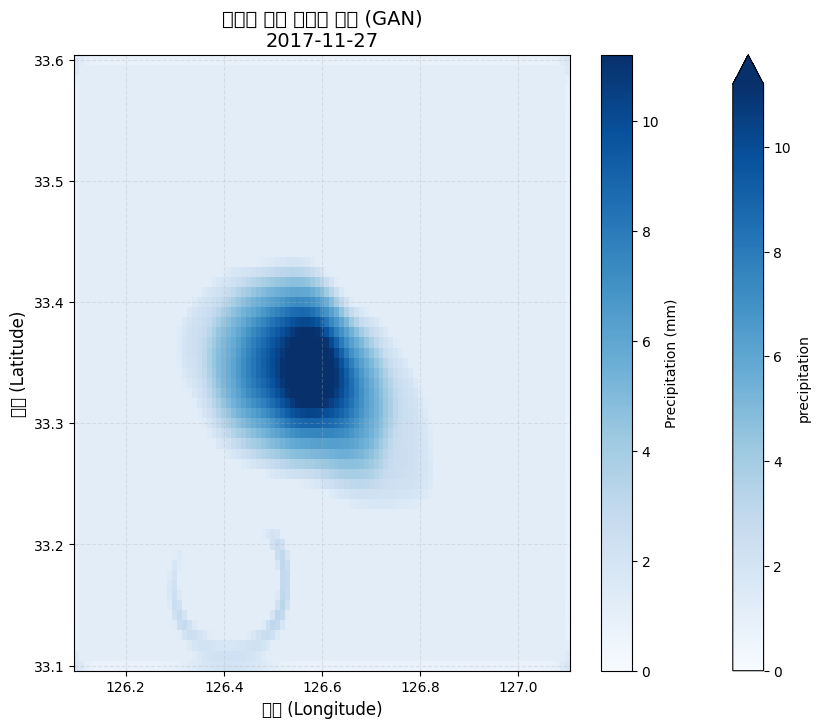

In [10]:
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 입력 폴더: .nc 파일들이 저장된 폴더
input_folder = r"C:\Yeonji\2025.01.Drought\GAN_Daily"

# 출력 폴더: PNG 파일들을 저장할 폴더
output_png_folder = r"C:\Yeonji\2025.01.Drought\GAN_Daily(png)"
if not os.path.exists(output_png_folder):
    os.makedirs(output_png_folder)

# 입력 폴더의 모든 .nc 파일 검색
nc_files = glob.glob(os.path.join(input_folder, "*_GAN_Prediction.nc"))

if not nc_files:
    print("입력 폴더에 GAN_Prediction.nc 파일이 없습니다.")
else:
    print(f"총 {len(nc_files)} 개의 NC 파일을 찾았습니다.")

# 각 파일별로 시각화
for nc_file in nc_files:
    try:
        # 파일 이름에서 날짜 추출 (YYYYMMDD)
        filename = os.path.basename(nc_file)
        date_str = filename.split('_')[0]  # YYYYMMDD 형식 추출
        
        # xarray로 데이터 로드
        ds = xr.open_dataset(nc_file)
        
        # precipitation 변수가 있는지 확인
        if "precipitation" in ds.data_vars:
            da = ds["precipitation"]
        else:
            # 첫 번째 변수 사용
            da = list(ds.data_vars.values())[0]
            print(f"'precipitation' 변수가 없어 {list(ds.data_vars.keys())[0]} 변수를 시각화합니다.")
        
        # 결측값 확인
        missing_pct = (np.isnan(da.values).sum() / da.size) * 100
        if missing_pct > 0:
            print(f"{filename}: 결측값 비율 {missing_pct:.2f}%")
        
        # 강수 데이터 범위를 고려한 색상 맵 설정
        plt.figure(figsize=(10, 8))
        
        # 0값이 많은 강수 데이터를 위한 설정
        vmax = np.nanpercentile(da.values, 99)  # 이상치 제외
        
        # 강수량에 적합한 색상맵 사용 (Blues는 강수에 적합)
        im = da.plot(cmap="Blues", vmin=0, vmax=vmax, add_colorbar=True)
        plt.colorbar(im, label="Precipitation (mm)")
        
        # 제목 및 축 레이블 설정
        formatted_date = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}"
        plt.title(f"제주도 상세 강수량 예측 (GAN)\n{formatted_date}", fontsize=14)
        plt.xlabel("경도 (Longitude)", fontsize=12)
        plt.ylabel("위도 (Latitude)", fontsize=12)
        
        # 격자선 추가
        plt.grid(alpha=0.3, linestyle='--')
        
        # 저장할 PNG 파일 경로
        png_file = os.path.join(output_png_folder, os.path.splitext(filename)[0] + ".png")
        plt.savefig(png_file, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"PNG 저장 완료: {png_file}")
        
    except Exception as e:
        print(f"{nc_file} 처리 중 오류 발생: {e}")

print("시각화 작업 완료!")

## 이건 뭐임?

In [2]:
import os
import datetime
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
from netCDF4 import Dataset as ncDataset
from tqdm import tqdm
import copy
import gc
import xarray as xr
import glob
from scipy.stats import gamma, norm
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

In [2]:
# SPI 계산 함수 정의
def compute_spi(precip_da, scale=3, dist='gamma'):
    """
    시간 스케일에 따른 SPI 계산
    
    Parameters:
    -----------
    precip_da : xarray.DataArray
        강수량 데이터 (시간 차원 포함)
    scale : int
        SPI 계산을 위한 시간 스케일 (개월)
    dist : str
        확률 분포 유형 ('gamma' 권장)
        
    Returns:
    --------
    xarray.DataArray
        계산된 SPI 값
    """
    
    # 적절한 시간 차원이 있는지 확인
    if 'time' not in precip_da.dims:
        raise ValueError("입력 DataArray에 'time' 차원이 없습니다.")
    
    # 롤링 평균 계산 (이동 윈도우)
    rolled = precip_da.rolling(time=scale, center=False).sum()
    
    # 첫 n-1개월은 NaN이므로 마스킹
    valid_data = rolled.where(~np.isnan(rolled))
    
    # 각 그리드 셀마다 SPI 계산
    def calculate_spi_for_cell(values):
        values = values[~np.isnan(values)]
        if len(values) < 10:  # 최소 데이터 포인트
            return np.nan
            
        if dist == 'gamma':
            # 감마 분포 피팅
            # 0보다 작은 값이나 0 값은 작은 양수로 대체
            values = np.where(values <= 0, 0.01, values)
            shape, loc, scale = stats.gamma.fit(values, floc=0)
            # 누적 확률 계산
            cdf = stats.gamma.cdf(values, shape, loc=loc, scale=scale)
            # 정규 분포의 역함수로 SPI 값 계산
            spi = stats.norm.ppf(cdf)
            return spi
        else:
            raise ValueError(f"지원되지 않는 분포 유형: {dist}")
    
    # GroupBy 연산으로 각 그리드 포인트마다 SPI 계산
    # month 차원을 추가하여 동일 월의 데이터끼리 비교
    time_vals = pd.DatetimeIndex(valid_data.time.values)
    valid_data = valid_data.assign_coords(month=("time", time_vals.month))
    
    # 각 월별로 그룹화하여 SPI 계산
    spi_vals = np.full_like(valid_data.values, np.nan)
    
    # 각 그리드 셀의 각 월별로 계산
    for month in range(1, 13):
        month_data = valid_data.where(valid_data.month == month, drop=False)
        month_indices = np.where(time_vals.month == month)[0]
        
        if len(month_indices) < 10:
            continue
            
        # 각 격자점마다 계산
        for i in range(valid_data.shape[1]):
            for j in range(valid_data.shape[2]):
                cell_vals = month_data[:, i, j].values
                valid_cell_vals = cell_vals[~np.isnan(cell_vals)]
                
                if len(valid_cell_vals) < 10:
                    continue
                    
                # 감마 분포 피팅
                valid_cell_vals = np.where(valid_cell_vals <= 0, 0.01, valid_cell_vals)
                try:
                    shape, loc, scale = stats.gamma.fit(valid_cell_vals, floc=0)
                    # 누적 확률 계산
                    cdf = stats.gamma.cdf(cell_vals, shape, loc=loc, scale=scale)
                    # 정규 분포의 역함수로 SPI 값 계산
                    spi = stats.norm.ppf(cdf)
                    spi_vals[month_indices, i, j] = spi
                except:
                    continue
    
    # 새 DataArray 생성
    spi_da = xr.DataArray(
        spi_vals,
        coords=valid_data.coords,
        dims=valid_data.dims,
        name=f'SPI-{scale}'
    )
    
    return spi_da

# 여러 시간 스케일의 SPI 계산 및 저장 함수
def compute_multi_scale_spi(monthly_precip, scales=[3, 6, 9, 12], output_folder=None):
    """
    여러 시간 스케일(3, 6, 9, 12개월 등)에 대한 SPI를 계산하고 저장
    
    Parameters:
    -----------
    monthly_precip : xarray.DataArray
        월별 강수량 데이터
    scales : list
        계산할 SPI 시간 스케일 리스트 (기본값: [3, 6, 9, 12])
    output_folder : str, optional
        결과 저장 폴더 경로 (None이면 저장하지 않음)
        
    Returns:
    --------
    dict
        각 스케일별 SPI DataArray 딕셔너리
    """
    import os
    import xarray as xr
    import pandas as pd
    
    spi_results = {}
    
    for scale in scales:
        print(f"SPI-{scale} 계산 중...")
        spi_da = compute_spi(monthly_precip, scale=scale)
        spi_results[scale] = spi_da
        
        # 저장 옵션이 제공된 경우
        if output_folder:
            spi_folder = os.path.join(output_folder, f"SPI{scale}")
            if not os.path.exists(spi_folder):
                os.makedirs(spi_folder)
            
            # 각 시간별로 개별 파일로 저장
            for t in range(spi_da.shape[0]):
                try:
                    time_val = pd.to_datetime(str(spi_da.time.values[t])).strftime("%Y%m")
                    spi_slice = spi_da.isel(time=t)
                    out_file = os.path.join(spi_folder, f"{time_val}_GAN_SPI{scale}.nc")
                    ds_spi = spi_slice.to_dataset(name=f"SPI{scale}")
                    ds_spi.to_netcdf(out_file)
                    print(f"SPI-{scale} 저장 완료: {out_file}")
                except Exception as e:
                    print(f"시간 {t}에 대한 SPI-{scale} 저장 중 오류 발생: {e}")
    
    return spi_results



In [3]:
#############################################
# 1. Dataset 정의 (일별 강수량 자료 로딩)
#############################################
class RainfallDataset(Dataset):
    def __init__(self, low_res_folder, high_res_folder, dem_file, start_date, end_date):
        self.low_res_folder = low_res_folder
        self.high_res_folder = high_res_folder
        self.dem_file = dem_file
        self.dates = [start_date + datetime.timedelta(days=i) 
                      for i in range((end_date - start_date).days + 1)]
        self.valid_data = self._filter_valid_data()
        self.dem_data = self._load_dem_data()
    
    def __len__(self):
        return len(self.valid_data)
    
    def __getitem__(self, idx):
        try:
            date = self.valid_data[idx]
            low_res_file = os.path.join(self.low_res_folder, date.strftime("%Y%m%d") + ".nc4")
            high_res_file = os.path.join(self.high_res_folder, date.strftime("%Y.%m.%d") + "_Cokriging_Precipitation.nc")
            
            low_res_data = self.load_and_resize_nc_file(low_res_file, 'precipitation', target_shape=(61, 101))
            high_res_data = self.load_nc_file(high_res_file, 'precipitation')
            dem_data = self.dem_data
            
            if low_res_data is None or high_res_data is None:
                raise FileNotFoundError(f"Missing data for date {date.strftime('%Y-%m-%d')}")
            
            # Normalize data
            low_res_data = self.normalize_data(low_res_data)
            dem_data = self.normalize_data(dem_data)
            
            # Add month as sine and cosine
            month = date.month
            month_sin = np.sin(2 * np.pi * month / 12)
            month_cos = np.cos(2 * np.pi * month / 12)
            
            month_sin_map = np.full(low_res_data.shape, month_sin, dtype=np.float32)
            month_cos_map = np.full(low_res_data.shape, month_cos, dtype=np.float32)
            
            low_res_data = torch.tensor(low_res_data, dtype=torch.float32).unsqueeze(0)
            high_res_data = torch.tensor(high_res_data, dtype=torch.float32).unsqueeze(0)
            dem_data = torch.tensor(dem_data, dtype=torch.float32).unsqueeze(0)
            month_sin_map = torch.tensor(month_sin_map, dtype=torch.float32).unsqueeze(0)
            month_cos_map = torch.tensor(month_cos_map, dtype=torch.float32).unsqueeze(0)
            
            # Combine channels: low_res, dem, sin(month), cos(month)
            input_data = torch.cat([low_res_data, dem_data, month_sin_map, month_cos_map], dim=0)
            
            return input_data, high_res_data
        except Exception as e:
            print(f"Error in __getitem__ for index {idx}: {str(e)}")
            raise e
    
    def normalize_data(self, data):
        mean = np.mean(data)
        std = np.std(data)
        if std == 0:
            return data - mean
        return (data - mean) / (std + 1e-8)
    
    def load_nc_file(self, file_path, var_name):
        try:
            with ncDataset(file_path, 'r') as nc_file:
                data = nc_file.variables[var_name][:].astype(np.float32)
                return data
        except FileNotFoundError:
            print(f"File {file_path} not found.")
            return None
        except Exception as e:
            print(f"Error loading {file_path}: {str(e)}")
            return None
    
    def load_and_resize_nc_file(self, file_path, var_name, target_shape):
        try:
            with ncDataset(file_path, 'r') as nc_file:
                data = nc_file.variables[var_name][:].astype(np.float32)
                if len(data.shape) == 3:
                    data = data.squeeze(0)
                data = torch.tensor(data, dtype=torch.float32)
                data = F.interpolate(
                    data.unsqueeze(0).unsqueeze(0), 
                    size=target_shape, 
                    mode='bilinear', 
                    align_corners=False
                ).squeeze()
                return data.numpy()
        except FileNotFoundError:
            print(f"File {file_path} not found.")
            return None
        except Exception as e:
            print(f"Error resizing {file_path}: {str(e)}")
            return None
    
    def _filter_valid_data(self):
        valid_dates = []
        for date in self.dates:
            low_res_file = os.path.join(self.low_res_folder, date.strftime("%Y%m%d") + ".nc4")
            high_res_file = os.path.join(self.high_res_folder, date.strftime("%Y.%m.%d") + "_Cokriging_Precipitation.nc")
            if os.path.exists(low_res_file) and os.path.exists(high_res_file):
                valid_dates.append(date)
        return valid_dates
    
    def _load_dem_data(self):
        try:
            with rasterio.open(self.dem_file) as dem_src:
                dem_data = dem_src.read(1)
                dem_data = self.normalize_data(dem_data)
                dem_data = torch.tensor(dem_data, dtype=torch.float32)
                dem_data = F.interpolate(
                    dem_data.unsqueeze(0).unsqueeze(0), 
                    size=(61, 101), 
                    mode='bilinear', 
                    align_corners=False
                ).squeeze()
                return dem_data.numpy()
        except FileNotFoundError:
            print(f"DEM file {self.dem_file} not found.")
            return None
        except Exception as e:
            print(f"Error loading DEM file {self.dem_file}: {str(e)}")
            return None


In [4]:
#############################################
# 2. GAN Generator (Downscaling 추론용; Discriminator는 불필요)
#############################################
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2)
        )
        # Enhanced attention module
        self.attention = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=1),
            nn.Sigmoid()
        )
        # Rainfall amplification branch
        self.rainfall_amp = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=1),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.ReLU()
        )
        # Enhanced rainfall intensity layer with skip connections
        self.enhancement = nn.ModuleList([
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.Conv2d(32, 1, kernel_size=1)
        ])
    
    def forward(self, x, target_shape):
        enc = self.encoder(x)
        att = self.attention(enc)
        enc_att = enc * att
        amp = self.rainfall_amp(enc_att)
        dec = self.decoder(enc_att)
        enhanced = dec
        for i, layer in enumerate(self.enhancement):
            if i == len(self.enhancement) - 1:
                enhanced = layer(enhanced) + amp
            else:
                enhanced = F.relu(layer(enhanced))
        enhanced = F.relu(enhanced) * 1.2
        output = F.interpolate(enhanced, size=target_shape, mode='bilinear', align_corners=False)
        return output

In [5]:
#############################################
# 3. Downscaling: 학습된 GAN generator를 이용해 일별 강수량 예측 (nc파일 저장)
#############################################
def downscale_data(low_res_folder, high_res_folder, dem_file, start_date, end_date, 
                   model_path, output_folder, target_shape=(61, 101)):
    dataset = RainfallDataset(low_res_folder, high_res_folder, dem_file, start_date, end_date)
    data_loader = DataLoader(dataset, batch_size=1, shuffle=False, pin_memory=True)
    
    # output_folder가 없으면 생성
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    generator = Generator().cuda()
    checkpoint = torch.load(model_path)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    generator.eval()
    
    predictions = []
    dates = dataset.valid_data  # valid한 날짜 리스트
    
    print("Downscaling (inference) 시작...")
    with torch.no_grad():
        for low_res, _ in tqdm(data_loader, desc="Downscaling"):
            low_res = low_res.cuda()
            output = generator(low_res, target_shape)
            pred = output.cpu().squeeze().numpy()
            predictions.append(pred)
    
    save_predictions_to_nc(predictions, dates, output_folder)
    print("Downscaling 완료 및 nc파일 저장됨.")
    return predictions, dates

def save_predictions_to_nc(predictions, dates, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Jeju 지역 (예시)
    jeju_lat_start, jeju_lat_end = 33.1, 33.6
    jeju_lon_start, jeju_lon_end = 126.1, 127.1
    
    lat_vals = np.linspace(jeju_lat_start, jeju_lat_end, predictions[0].shape[0])
    lon_vals = np.linspace(jeju_lon_start, jeju_lon_end, predictions[0].shape[1])
    
    for pred, date in zip(predictions, dates):
        filename = os.path.join(output_folder, f"{date.strftime('%Y%m%d')}_GAN_Prediction.nc")
        try:
            with ncDataset(filename, 'w', format='NETCDF4') as nc:
                nc.createDimension('latitude', pred.shape[0])
                nc.createDimension('longitude', pred.shape[1])
                
                lats = nc.createVariable('latitude', 'f4', ('latitude',))
                lons = nc.createVariable('longitude', 'f4', ('longitude',))
                precip = nc.createVariable('precipitation', 'f4', ('latitude', 'longitude'))
                
                lats[:] = lat_vals
                lons[:] = lon_vals
                precip[:, :] = pred
                
                nc.description = 'GAN Downscaled Precipitation Prediction with DEM and Seasonal Encoding'
                nc.date = date.strftime('%Y-%m-%d')
            print(f"저장 성공: {date.strftime('%Y-%m-%d')}")
        except Exception as e:
            print(f"{date.strftime('%Y-%m-%d')} 예측 저장 실패: {str(e)}")

In [6]:
#############################################
# 4. 집계: 일별 nc파일들을 월별 강수량 자료로 개별 저장 (파일명: yyyymm_GAN_Prediction.nc)
#############################################
def aggregate_daily_to_monthly_individual(input_folder, monthly_output_folder):
    """
    input_folder: 일별 예측 nc파일들이 저장된 폴더 (파일명: yyyymmdd_GAN_Prediction.nc)
    monthly_output_folder: 월별 자료 저장 폴더
    """
    if not os.path.exists(monthly_output_folder):
        os.makedirs(monthly_output_folder)
    
    file_list = sorted(glob.glob(os.path.join(input_folder, "*_GAN_Prediction.nc")))
    
    # 그룹핑: (year, month) 별로 파일 모으기
    monthly_dict = {}
    for file in file_list:
        base = os.path.basename(file)
        try:
            # 파일명에서 날짜 추출 (예: 20160115_GAN_Prediction.nc)
            date = datetime.datetime.strptime(base[:8], "%Y%m%d")
        except Exception as e:
            print(f"파일명 {base}에서 날짜 추출 오류: {e}")
            continue
        ym = date.strftime("%Y%m")
        monthly_dict.setdefault(ym, []).append(file)
    
    monthly_dataarrays = []
    time_list = []
    
    # 각 월별로 일별 파일 읽어 합산
    for ym, files in sorted(monthly_dict.items()):
        daily_da_list = []
        for file in files:
            try:
                ds = xr.open_dataset(file)
                # 변수명이 'precipitation'라고 가정
                da = ds['precipitation']
                daily_da_list.append(da)
                ds.close()
            except Exception as e:
                print(f"{file} 처리 오류: {e}")
        if daily_da_list:
            # 시간 축이 없는 DataArray들이면 expand_dims로 추가 후 합산
            daily_concat = xr.concat([da.expand_dims(time=[0]) if 'time' not in da.dims else da for da in daily_da_list], dim="time")
            # 월별 누적합 계산 (모든 일의 합)
            monthly_sum = daily_concat.sum(dim="time")
            # 시간 좌표는 해당 월의 첫날로 지정
            time_val = np.datetime64(datetime.datetime.strptime(ym, "%Y%m"))
            monthly_sum = monthly_sum.expand_dims(time=[time_val])
            monthly_sum = monthly_sum.rename("precipitation")
            monthly_dataarrays.append(monthly_sum)
            time_list.append(time_val)
            # 저장: 파일명 yyyymm_GAN_Prediction.nc
            out_filename = os.path.join(monthly_output_folder, f"{ym}_GAN_Prediction.nc")
            ds_month = monthly_sum.to_dataset()
            ds_month.to_netcdf(out_filename)
            print(f"월별 자료 저장 완료: {out_filename}")
    
    # Combine all monthly DataArrays into one dataset for further processing
    if monthly_dataarrays:
        monthly_ds = xr.concat(monthly_dataarrays, dim="time")
        monthly_ds = monthly_ds.assign_coords(time=("time", sorted(time_list)))
        return monthly_ds
    else:
        return None

In [7]:
#############################################
# Main 실행 파트 (수정)
#############################################
if __name__ == "__main__":
    # -----------------------------
    # 설정: 자료 경로, 날짜 범위 등
    # -----------------------------
    start_date = datetime.date(2016, 1, 1)
    end_date = datetime.date(2023, 12, 31)
    
    # 폴더 및 파일 경로 (사용자 환경에 맞게 수정)
    low_res_folder = r'G:\24.11.Graduate\0.Rawdata\GPM_IMERG_Clipped'
    high_res_folder = r'G:\24.11.Graduate\1.CoKriging'
    dem_file = r"G:\24.11.Graduate\DEM_Jeju.tif"
    output_folder = r'C:\Yeonji\2025.01.Drought\Output(NEW)'
    model_path = r"G:\24.11.Graduate\2.GAN_Predictions(7)\gan_model_seasonal.pth"
    
    # output_folder가 없으면 생성
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # (1) Downscaling: 일별 강수량 예측 파일 생성 (파일명: yyyymmdd_GAN_Prediction.nc)
    print("1. Downscaling 시작...")
    predictions, valid_dates = downscale_data(low_res_folder, high_res_folder, dem_file,
                                              start_date, end_date, model_path, output_folder,
                                              target_shape=(61, 101))
    
    # (2) 집계: 일별 nc파일들을 월별 자료로 개별 저장 (파일명: yyyymm_GAN_Prediction.nc)
    monthly_folder = os.path.join(output_folder, "Monthly")
    if not os.path.exists(monthly_folder):
        os.makedirs(monthly_folder)
    monthly_ds = aggregate_daily_to_monthly_individual(output_folder, monthly_folder)
    if monthly_ds is None:
        print("월별 자료 집계 실패.")
        exit(1)
    
    # 반환된 monthly_ds가 DataArray이면 그대로 사용, 아니면 'precipitation' 변수 추출
    if isinstance(monthly_ds, xr.DataArray):
        monthly_precip = monthly_ds
    else:
        monthly_precip = monthly_ds['precipitation']
    
    # (3) 여러 시간 스케일(3, 6, 9, 12개월)의 SPI 계산
    print("3. 다중 시간 스케일 SPI 계산 시작...")
    spi_output_folder = os.path.join(output_folder, "SPI")
    spi_results = compute_multi_scale_spi(
        monthly_precip, 
        scales=[3, 6, 9, 12],  # SPI 계산할 시간 스케일
        output_folder=spi_output_folder
    )
    
    # 결과 요약 출력
    for scale, spi_da in spi_results.items():
        valid_points = np.sum(~np.isnan(spi_da.values))
        print(f"SPI-{scale} 계산 완료: 유효 데이터 포인트 {valid_points}개")
    
    torch.cuda.empty_cache()
    gc.collect()
    print("전체 파이프라인 완료!")

1. Downscaling 시작...
Downscaling (inference) 시작...


Downscaling: 100%|██████████| 2921/2921 [2:33:28<00:00,  3.15s/it]  


저장 성공: 2016-01-01
저장 성공: 2016-01-02
저장 성공: 2016-01-03
저장 성공: 2016-01-04
저장 성공: 2016-01-05
저장 성공: 2016-01-06
저장 성공: 2016-01-07
저장 성공: 2016-01-08
저장 성공: 2016-01-09
저장 성공: 2016-01-10
저장 성공: 2016-01-11
저장 성공: 2016-01-12
저장 성공: 2016-01-13
저장 성공: 2016-01-14
저장 성공: 2016-01-15
저장 성공: 2016-01-16
저장 성공: 2016-01-17
저장 성공: 2016-01-18
저장 성공: 2016-01-19
저장 성공: 2016-01-20
저장 성공: 2016-01-21
저장 성공: 2016-01-22
저장 성공: 2016-01-23
저장 성공: 2016-01-24
저장 성공: 2016-01-25
저장 성공: 2016-01-26
저장 성공: 2016-01-27
저장 성공: 2016-01-28
저장 성공: 2016-01-29
저장 성공: 2016-01-30
저장 성공: 2016-01-31
저장 성공: 2016-02-01
저장 성공: 2016-02-02
저장 성공: 2016-02-03
저장 성공: 2016-02-04
저장 성공: 2016-02-05
저장 성공: 2016-02-06
저장 성공: 2016-02-07
저장 성공: 2016-02-08
저장 성공: 2016-02-09
저장 성공: 2016-02-10
저장 성공: 2016-02-11
저장 성공: 2016-02-12
저장 성공: 2016-02-13
저장 성공: 2016-02-14
저장 성공: 2016-02-15
저장 성공: 2016-02-16
저장 성공: 2016-02-17
저장 성공: 2016-02-18
저장 성공: 2016-02-19
저장 성공: 2016-02-20
저장 성공: 2016-02-21
저장 성공: 2016-02-22
저장 성공: 2016-02-23
저장 성공: 2016-02-24
저장 성공: 201